In [1]:
import os
import sys
sys.path.append("../../")

from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.conditioning import conditioning
from biked_commons.resource_utils import datasets_path
from biked_commons.benchmark_models import benchmarking_utils
from biked_commons.benchmark_models.generative_modeling_utils import sample_continuous
from biked_commons.design_evaluation.score_report import ScoreReportDashboard

c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import importlib
importlib.reload(benchmarking_utils)
scores = benchmarking_utils.create_score_report_conditional()
#turn constraint satisfaction rate into a percent with two decimal places
scores['Constraint Satisfaction Rate'] = scores['Constraint Satisfaction Rate'] * 100
scores['Constraint Satisfaction Rate'] = scores['Constraint Satisfaction Rate'].apply(lambda x: "{:.2f}%".format(x))

#four decimals for Hypervolume and Maximum Mean Discrepancy
scores['Hypervolume'] = scores['Hypervolume'].apply(lambda x: "{:.4f}".format(x))
scores['Maximum Mean Discrepancy'] = scores['Maximum Mean Discrepancy'].apply(lambda x: "{:.4f}".format(x))


savedir = os.path.join("results", "cond_overall_scores.csv")
scores.to_csv(savedir, index=False)
display(scores)

,Constraint Satisfaction Rate,Hypervolume,Maximum Mean Discrepancy
CTGAN,0.87%,0.4090,0.0324
DDPM_conditional-PA,40.46%,0.3801,0.0590
DDPM_guided-PA,40.30%,0.4120,0.0253
Dataset,3.14%,0.4447,0.0006
GAN-PA,22.34%,0.4152,0.1791
O4-mini,0.63%,0.2615,0.3460
TVAE,0.00%,0.0000,0.0365
VAE-PA,81.65%,0.4357,0.0693


In [3]:
scores = benchmarking_utils.create_score_report_unconditional()
#turn constraint satisfaction rate into a percent with two decimal places
scores['Constraint Satisfaction Rate'] = scores['Constraint Satisfaction Rate'] * 100
scores['Constraint Satisfaction Rate'] = scores['Constraint Satisfaction Rate'].apply(lambda x: "{:.2f}%".format(x))

#four decimals for Hypervolume and Maximum Mean Discrepancy
scores['Hypervolume'] = scores['Hypervolume'].apply(lambda x: "{:.4f}".format(x))
scores['Maximum Mean Discrepancy'] = scores['Maximum Mean Discrepancy'].apply(lambda x: "{:.4f}".format(x))

savedir = os.path.join("results", "uncond_overall_scores.csv")
scores.to_csv(savedir, index=False)
display(scores)

,Constraint Satisfaction Rate,Hypervolume,Maximum Mean Discrepancy
Agg-LS,98.55%,0.3648,0.3824
CTGAN,0.58%,0.1496,0.0252
DDPM_conditional-PA,54.24%,0.2750,0.0740
DDPM_guided-PA,40.57%,0.2957,0.0261
Dataset,2.60%,0.2817,0.0007
EPO,92.00%,0.2625,0.2286
GAN-PA,24.16%,0.3228,0.1066
NSGA2,100.00%,0.4293,0.5051
O4-mini,0.28%,0.0115,0.5026
TVAE,0.05%,0.0334,0.0400


c:\Users\Lyler\Documents\Bike-Bench-Temporary\src\biked_commons\benchmark_models\../..\biked_commons\design_evaluation\score_report.py:99: UserWarning: No model_colors provided; using Matplotlib cycle.
  warnings.warn("No model_colors provided; using Matplotlib cycle.")


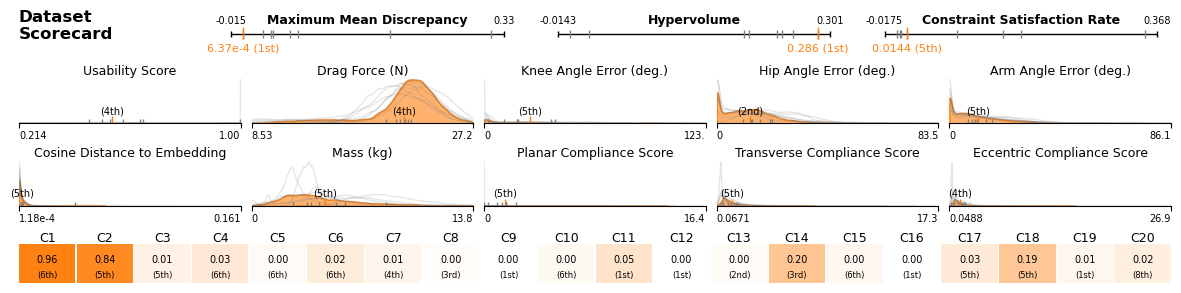

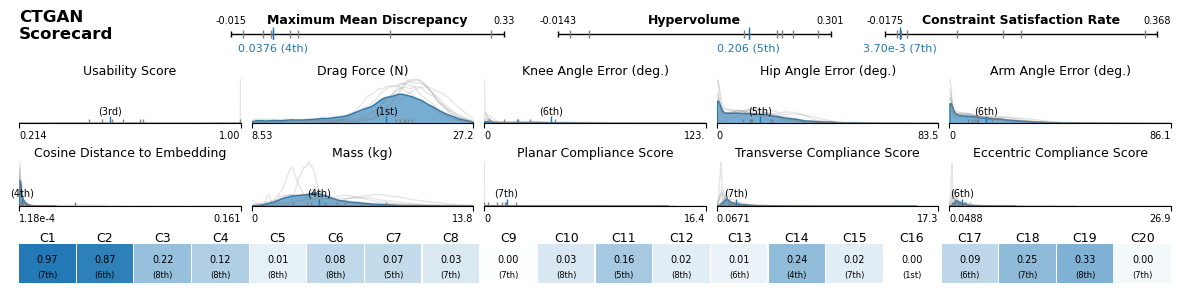

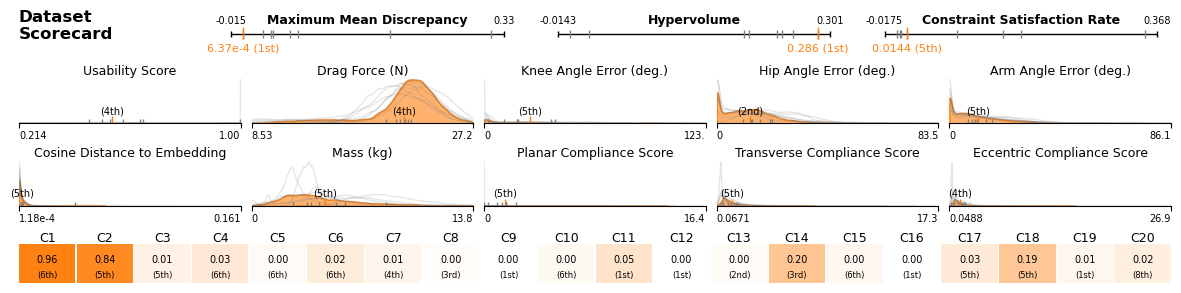

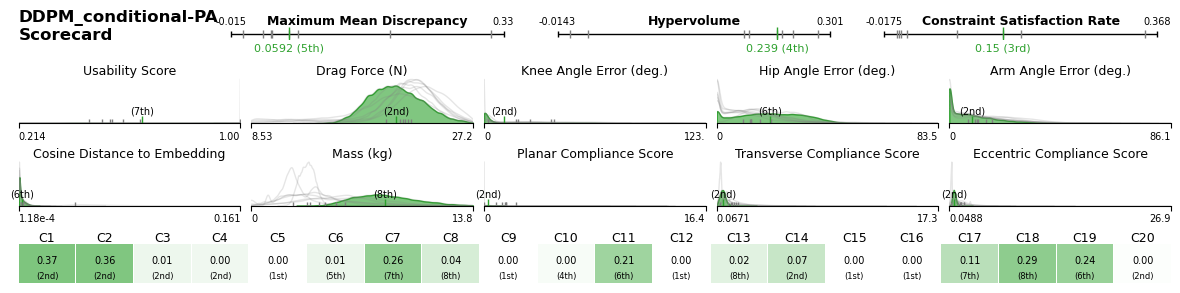

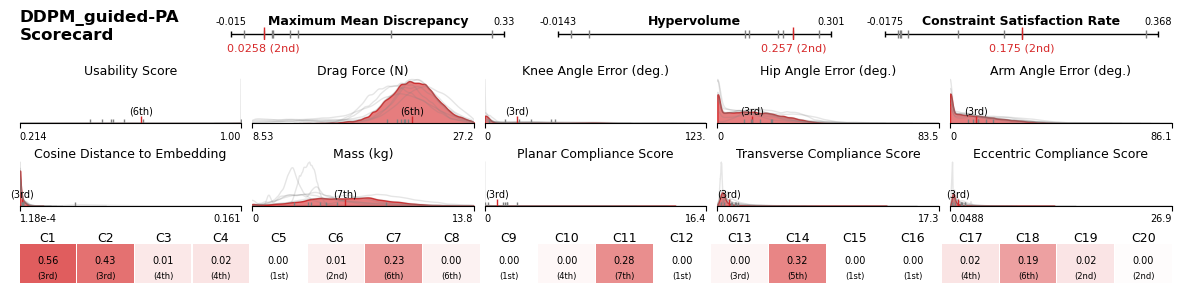

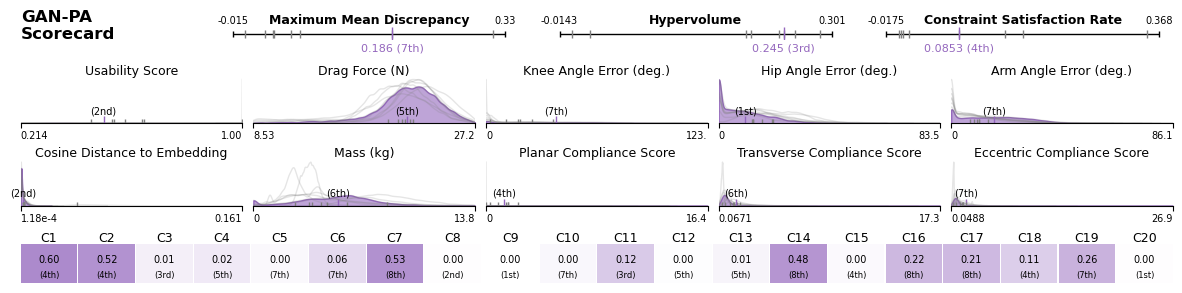

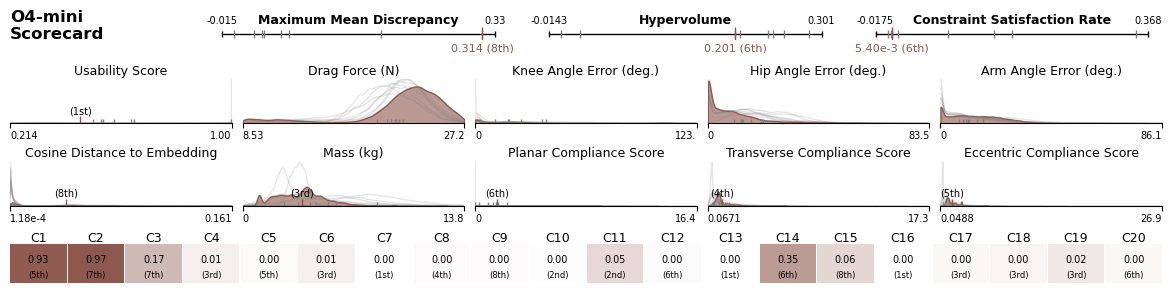

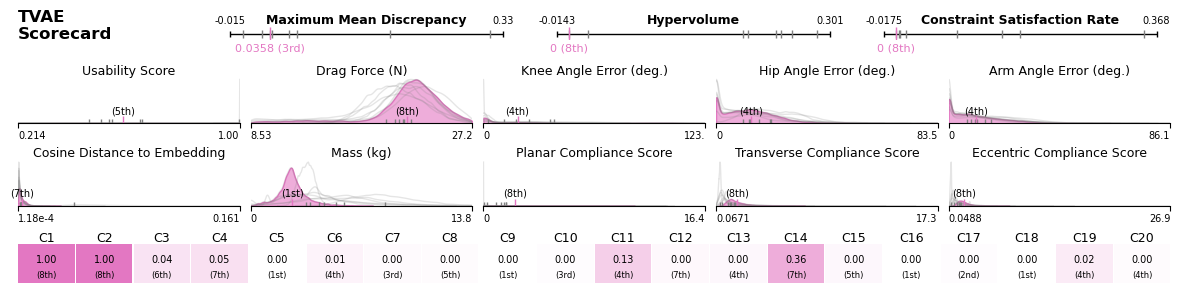

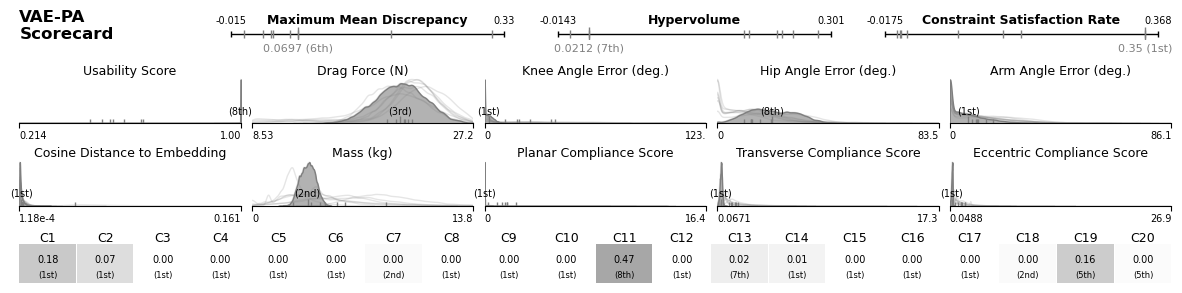

In [3]:
def create_scorecards_conditional(device="cuda"):

    data = data_loading.load_bike_bench_train()
    all_result_tens = []
    result_dir = os.path.join("results", "conditional")
    all_names = os.listdir(result_dir)
    for name in all_names:
        if os.path.isdir(os.path.join(result_dir, name)):
            result_tens = torch.load(os.path.join(result_dir, name, "result_tens.pt"))
            all_result_tens.append(result_tens)
    num_samples=10000
    split = "test"
    randomize = False
    emb = conditioning.sample_image_embedding(num_samples, split, randomize)
    rider = conditioning.sample_riders(num_samples, split, randomize)
    use_case = conditioning.sample_use_case(num_samples, split, randomize)
    condition = {"Rider": rider, "Use Case": use_case, "Embedding": emb}

    dashboard = ScoreReportDashboard(
    design_batches   = all_result_tens,
    eval_funcs       = get_standard_evaluations(device),
    model_names      = all_names,
    condition        = condition,
    column_names     = data.columns.tolist(),
    device           = device
    )

    for name in all_names:
        dashboard.show_model(name)
    
create_scorecards_conditional(device="cpu")

c:\Users\Lyler\Documents\Bike-Bench-Temporary\src\biked_commons\benchmark_models\../..\biked_commons\design_evaluation\score_report.py:99: UserWarning: No model_colors provided; using Matplotlib cycle.
  warnings.warn("No model_colors provided; using Matplotlib cycle.")


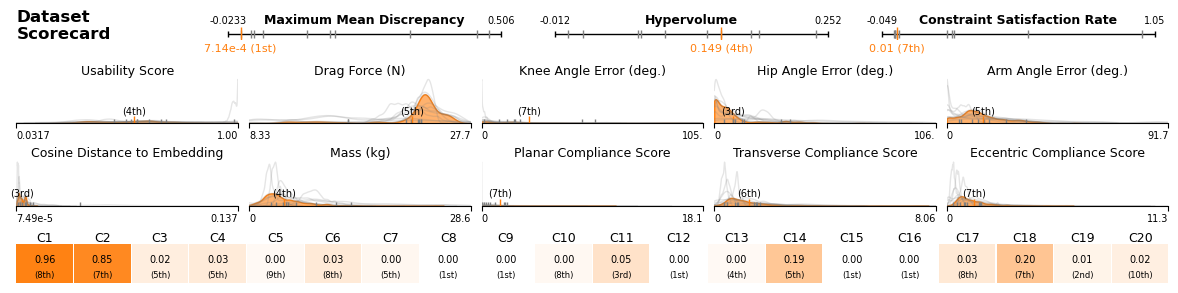

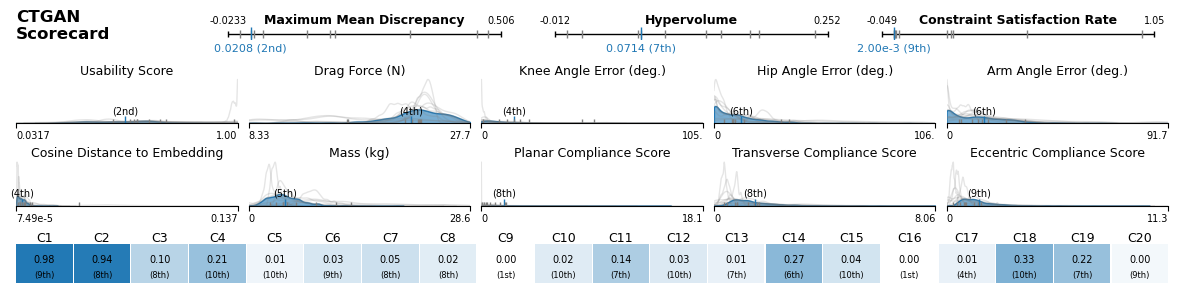

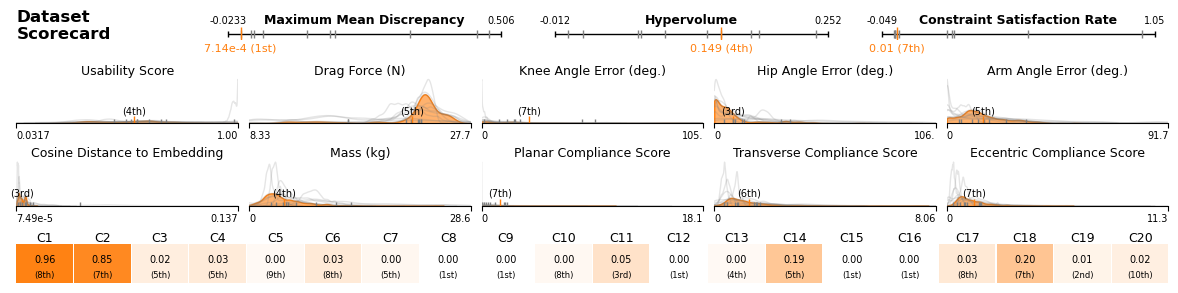

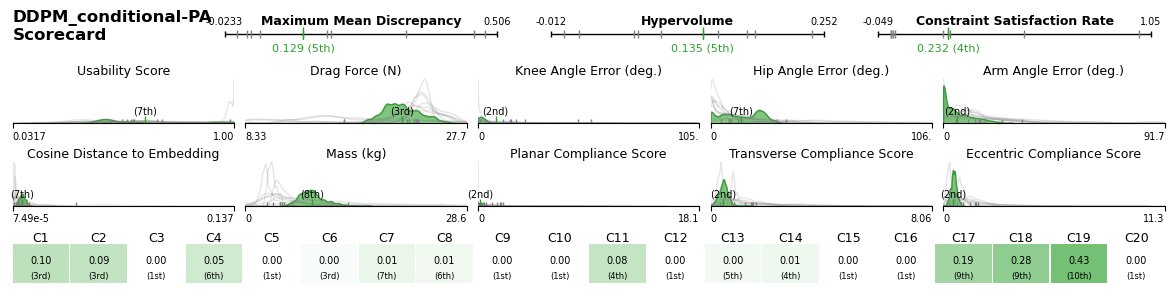

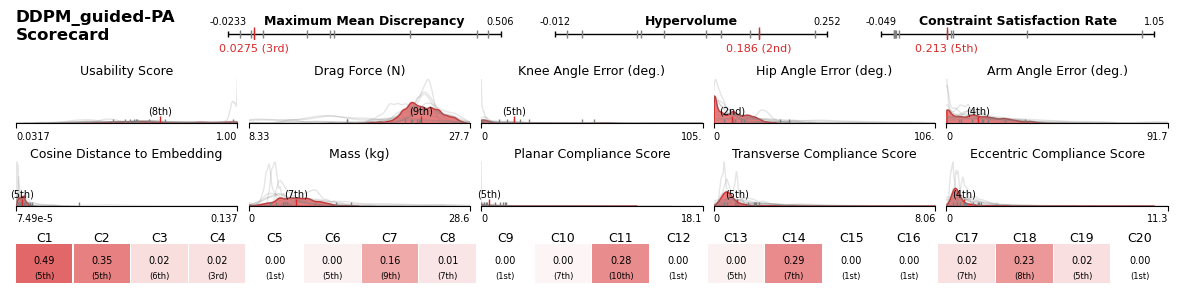

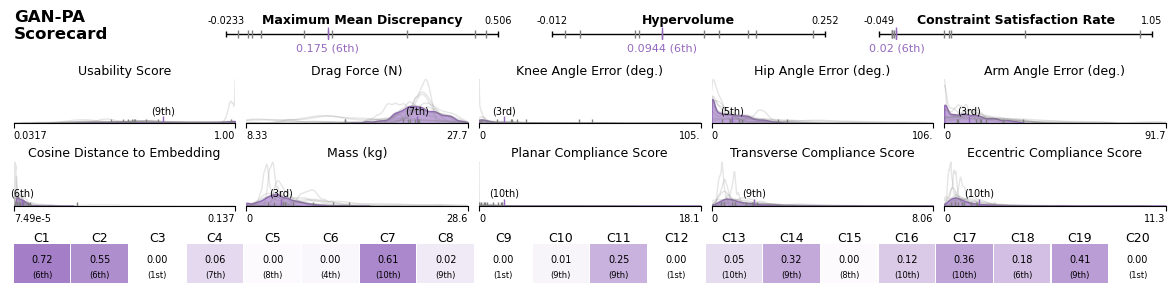

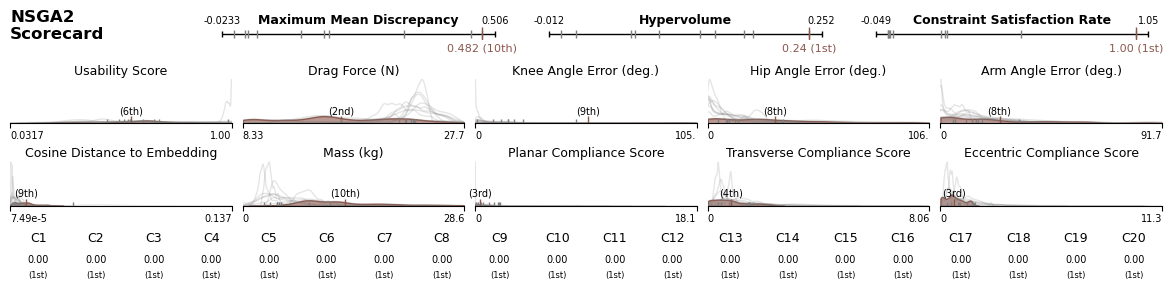

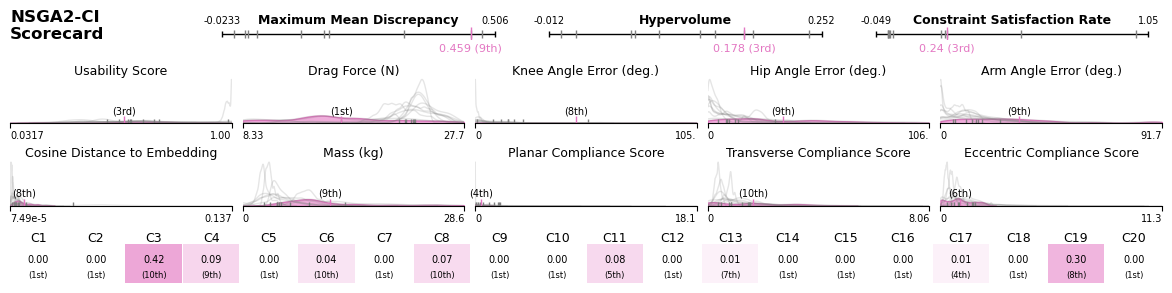

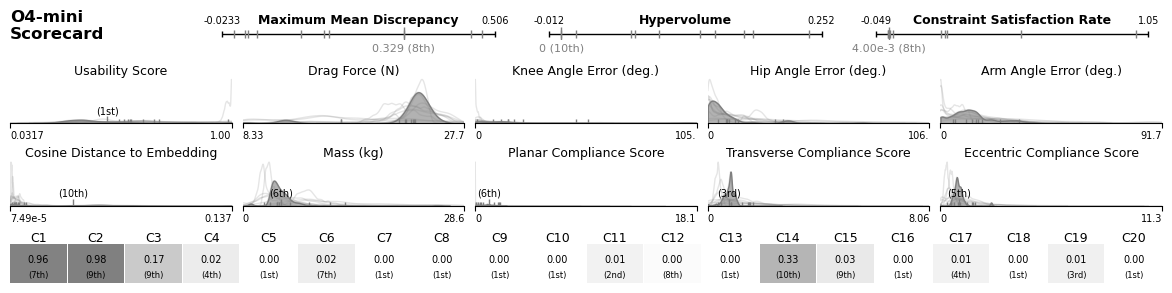

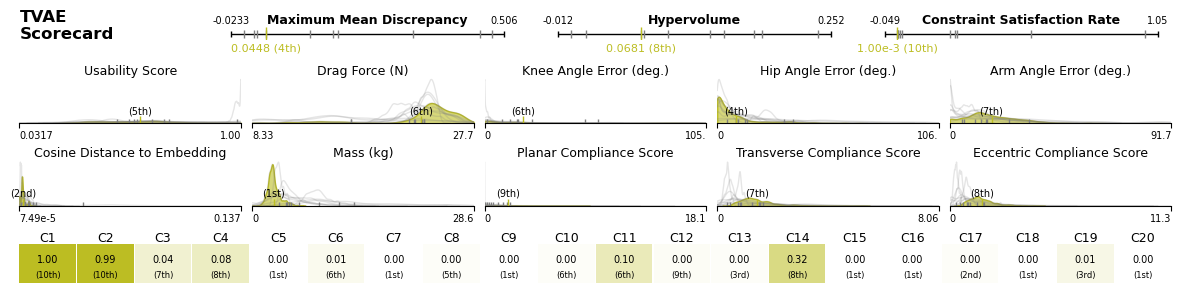

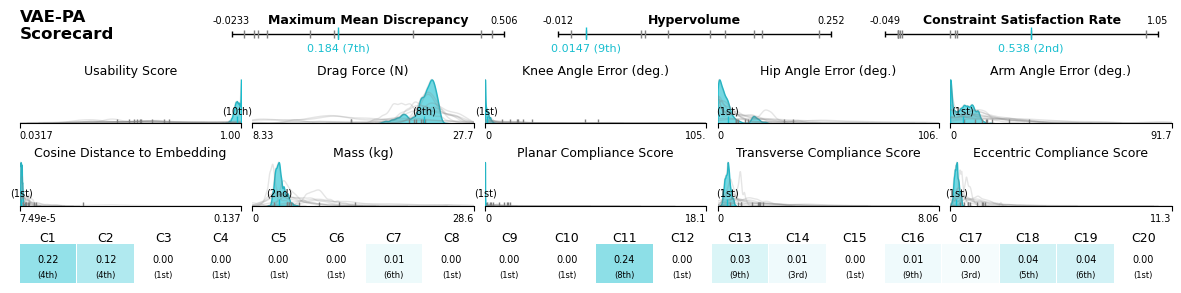

In [4]:
def create_scorecards_unconditional(device="cuda", cond_idx=0):

    data = data_loading.load_bike_bench_train()
    all_result_tens = []
    result_dir = os.path.join("results", "unconditional", f"cond_{cond_idx}")
    all_names = os.listdir(result_dir)
    for name in all_names:
        if os.path.isdir(os.path.join(result_dir, name)):
            result_tens = torch.load(os.path.join(result_dir, name, "result_tens.pt"))
            all_result_tens.append(result_tens)
    num_samples=10
    split = "test"
    randomize = False
    emb = conditioning.sample_image_embedding(num_samples, split, randomize)
    rider = conditioning.sample_riders(num_samples, split, randomize)
    use_case = conditioning.sample_use_case(num_samples, split, randomize)
    condition = {"Rider": rider[cond_idx], "Use Case": use_case[cond_idx], "Embedding": emb[cond_idx]}

    dashboard = ScoreReportDashboard(
    design_batches   = all_result_tens,
    eval_funcs       = get_standard_evaluations(device),
    model_names      = all_names,
    condition        = condition,
    column_names     = data.columns.tolist(),
    device           = device
    )
    dashboard.show_model("Dataset")

    for name in all_names:
        dashboard.show_model(name)
    
create_scorecards_unconditional(device="cuda")